### Load Data

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("anl123456/brain-data")

print("Path to dataset files:", path)

In [ ]:
import os
import nibabel as nib
import numpy as np
import pandas as pd
from PIL import Image

data_dir = "/kaggle/input/brain-data/data"
label_file = os.path.join(data_dir, "participants.xlsx")
df_labels = pd.read_excel(label_file)
df_labels['subject_id'] = df_labels['subject_id'].str.strip()

os.makedirs("middle_slices", exist_ok=True)

for folder in os.listdir(data_dir):
    subject_path = os.path.join(data_dir, folder, "anat")
    if not os.path.isdir(subject_path):
        continue

    
    nii_path = None
    for root, _, files in os.walk(subject_path):
        for file in files:
            if file.endswith(".nii"):
                nii_path = os.path.join(root, file)
                break
        if nii_path:
            break

    if not nii_path:
        print(f"[SKIP] Không tìm thấy file .nii trong {subject_path}")
        continue

    if os.path.getsize(nii_path) == 0:
        print(f"[SKIP] {nii_path} là file rỗng.")
        continue

    try:
        img = nib.load(nii_path)
        data = img.get_fdata()

        
        mid_slice = data[:, :, data.shape[2] // 2]
        mid_slice = np.rot90(mid_slice)
        norm_img = ((mid_slice - mid_slice.min()) / (mid_slice.max() - mid_slice.min()) * 255).astype(np.uint8)

        img_pil = Image.fromarray(norm_img).resize((224, 224))
        img_pil.save(f"middle_slices/{folder}.png")

        
        match = df_labels[df_labels['subject_id'] == folder]
        if not match.empty:
            age = match.iloc[0]['subject_age']
            print(f"{folder}: age = {age}")
        else:
            print(f"{folder}: label not found.")
    except Exception as e:
        print(f"[ERROR] {folder} - {e}")


### Split data

In [ ]:
import os
import nibabel as nib
import numpy as np
import pandas as pd
from PIL import Image

def age_to_label(age):
    if age <= 20:
        return "20"
    elif age <= 30:
        return "30"
    elif age <= 40:
        return "40"
    elif age <= 50:
        return "50"
    elif age <= 60:
        return "60"
    elif age <= 70:
        return "70"
    else:
        return "80"

data_dir = "/kaggle/input/brain-data/data"
label_file = os.path.join(data_dir, "participants.xlsx")
output_dir = "middle_slices"


try:
    df_labels = pd.read_excel(label_file)
    df_labels['subject_id'] = df_labels['subject_id'].str.strip()
except Exception as e:
    print(f"[ERROR] Không thể đọc file nhãn: {e}")
    exit(1)

age_labels = ["20", "30", "40", "50", "60", "70", "80"]
for label in age_labels:
    os.makedirs(os.path.join(output_dir, label), exist_ok=True)

for folder in os.listdir(data_dir):
    subject_path = os.path.join(data_dir, folder, "anat")
    if not os.path.isdir(subject_path):
        print(f"[SKIP] anat not found: {subject_path}")
        continue

    
    nii_path = None
    for root, _, files in os.walk(subject_path):
        nii_files = [f for f in files if f.endswith(".nii")]
        if nii_files:
            nii_path = os.path.join(root, nii_files[0])
            if len(nii_files) > 1:
                print(f"[WARNING] too many file .nii{subject_path}: {nii_files}")
            break

    if not nii_path:
        print(f"[SKIP] file .nii not found {subject_path}")
        continue

    if os.path.getsize(nii_path) == 0:
        print(f"[SKIP] {nii_path} empty.")
        continue

    try:
        
        img = nib.load(nii_path)
        data = img.get_fdata()

        mid_slice = data[:, :, data.shape[2] // 2]
        mid_slice = np.rot90(mid_slice)

        lower, upper = np.percentile(mid_slice, [1, 99])
        mid_slice = np.clip(mid_slice, lower, upper)
        norm_img = ((mid_slice - mid_slice.min()) / (mid_slice.max() - mid_slice.min() + 1e-8) * 255).astype(np.uint8)

        subject_id = folder
        if subject_id.startswith("sub-"):
            subject_id = subject_id[4:]  
        match = df_labels[df_labels['subject_id'].str.contains(subject_id, case=False)]
        if not match.empty:
            age = match.iloc[0]['subject_age']
            age_label = age_to_label(age)
            print(f"{folder}: age = {age}, label = {age_label}")
        else:
            print(f"{folder}: label not found.")
            continue

        # Lưu ảnh vào thư mục theo nhãn tuổi
        output_path = os.path.join(output_dir, age_label, f"{folder}.png")
        img_pil = Image.fromarray(norm_img).resize((224, 224))
        img_pil.save(output_path)
        print(f"[SUCCESS] save image: {output_path}")

    except nib.fileholders.FileHolderError as e:
        print(f"[ERROR] file cant read {nii_path}: {e}")
    except Exception as e:
        print(f"[ERROR]  {folder} fail: {e}")

In [ ]:
import os
import matplotlib.pyplot as plt
from PIL import Image


age_labels = [20, 30, 40, 50, 60, 70, 80]
base_dir = "middle_slices"


plt.figure(figsize=(14, 4))

for i, label in enumerate(age_labels):
    label_dir = os.path.join(base_dir, str(label))
    if not os.path.exists(label_dir):
        print(f"[⚠️] Folder {label_dir} không tồn tại.")
        continue

    image_files = [f for f in os.listdir(label_dir) if f.lower().endswith((".png", ".jpg", ".jpeg"))]
    if not image_files:
        print(f"[⚠️] imgae not found on {label_dir}")
        continue

    image_path = os.path.join(label_dir, image_files[0])
    image = Image.open(image_path).convert("L")  # chuyển về grayscale nếu cần

    plt.subplot(1, len(age_labels), i + 1)
    plt.imshow(image, cmap="gray")
    plt.title(f"Label: {label}")
    plt.axis("off")

plt.tight_layout()
plt.show()


In [ ]:
import torch
import torch.nn as nn
import torchvision
import torchvision.utils as vutils
import matplotlib.pyplot as plt
import numpy as np
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import os

# 2. Thiết lập tham số
image_size = 128
batch_size = 64
nz = 100               #  vector noise size
ngf = 128              #  feature map cho Generator
ndf = 128              #  feature map cho Discriminator
nc = 1                 #  grayscale
n_classes = 7         
num_epochs = 700

label_smoothing = 0.9  #  label smoothing

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 3. Tiền xử lý ảnh
transform = transforms.Compose([
    transforms.Grayscale(),
    transforms.Resize(image_size),
    transforms.CenterCrop(image_size),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5]),
])


dataset = datasets.ImageFolder(root="middle_slices", transform=transform)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)


label_map = {0: 20, 1: 30, 2: 40, 3: 50, 4: 60, 5: 70, 6: 80}
print("Class to age map:", dataset.class_to_idx)


## Model 

### Generator

In [ ]:

class Generator(nn.Module):
    def __init__(self, nz, ngf, nc, n_classes):
        super().__init__()
        self.label_emb = nn.Embedding(n_classes, n_classes)
        self.main = nn.Sequential(
            nn.ConvTranspose2d(nz + n_classes, ngf * 16, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf * 16),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf * 16, ngf * 8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 8),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf * 8, ngf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 4),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf * 4, ngf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 2),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf * 2, ngf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf, nc, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, noise, labels):
        label_emb = self.label_emb(labels).unsqueeze(2).unsqueeze(3)
        input = torch.cat([noise, label_emb], dim=1)
        return self.main(input)

### Discriminator

In [ ]:

class Discriminator(nn.Module):
    def __init__(self, nc, ndf, n_classes):
        super().__init__()
        self.label_emb = nn.Embedding(n_classes, n_classes)
        self.main = nn.Sequential(
            nn.Conv2d(nc + n_classes, ndf, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 2),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf * 2, ndf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 4),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf * 4, ndf * 8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 8),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf * 8, ndf * 16, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 16),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf * 16, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
        )

    def forward(self, img, labels):
        label_emb = self.label_emb(labels).unsqueeze(2).unsqueeze(3)
        label_emb = label_emb.expand(-1, -1, img.size(2), img.size(3))
        input = torch.cat([img, label_emb], dim=1)
        return self.main(input)

In [ ]:
netG = Generator(nz, ngf, nc, n_classes).to(device)
netD = Discriminator(nc, ndf, n_classes).to(device)

criterion = nn.BCELoss()
optimizerG = torch.optim.Adam(netG.parameters(), lr=0.0002, betas=(0.5, 0.999))
optimizerD = torch.optim.Adam(netD.parameters(), lr=0.0002, betas=(0.5, 0.999))


fixed_noise = torch.randn(128, nz, 1, 1, device=device)
fixed_labels = torch.full((128,), 1, dtype=torch.long, device=device)  # label=30 → index=1


### Train 

In [ ]:
for epoch in range(num_epochs):
    for i, (real_images, labels) in enumerate(dataloader):
        real_images, labels = real_images.to(device), labels.to(device)
        b_size = real_images.size(0)

        
        # -----------------
        #  Train Discriminator
        # -----------------
        netD.zero_grad()
        real_output = netD(real_images, labels).view(-1)
        lossD_real = criterion(real_output, torch.ones_like(real_output))

        noise = torch.randn(b_size, nz, 1, 1, device=device)
        fake_images = netG(noise, labels)
        fake_output = netD(fake_images.detach(), labels).view(-1)
        lossD_fake = criterion(fake_output, torch.zeros_like(fake_output))

        lossD = lossD_real + lossD_fake
        lossD.backward()
        optimizerD.step()

        # -----------------
        #  Train Generator
        # -----------------
        netG.zero_grad()
        noise = torch.randn(b_size, nz, 1, 1, device=device)
        fake_images = netG(noise, labels)
        output = netD(fake_images, labels).view(-1)
        lossG = criterion(output, torch.ones_like(output))
        lossG.backward()
        optimizerG.step()

        if i % 100 == 0:
            print(f"[{epoch}/{num_epochs}][{i}/{len(dataloader)}] Loss_D: {lossD.item():.4f} Loss_G: {lossG.item():.4f}")


    with torch.no_grad():
        fake = netG(fixed_noise, fixed_labels).detach().cpu()
        img_grid = vutils.make_grid(fake[:16], normalize=True, nrow=4)

        plt.figure(figsize=(6,6))
        plt.axis("off")
        plt.title(f"Epoch {epoch} - Age 30")
        plt.imshow(np.transpose(img_grid, (1, 2, 0)))
        plt.show()

        vutils.save_image(fake, f"epoch_{epoch:03}_label30.png", normalize=True)


In [25]:
import os
os.makedirs("checkpoints", exist_ok=True)


In [26]:
torch.save(netG.state_dict(), f"checkpoints/netG_epoch_{epoch}.pth")
torch.save(netD.state_dict(), f"checkpoints/netD_epoch_{epoch}.pth")


In [13]:

nz = 100
ngf = 128
nc = 1
n_classes = 7  # [20, 30, ..., 80]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

#  load weight
netG = Generator(nz, ngf, nc, n_classes).to(device)
netG.load_state_dict(torch.load("checkpoints/netG_epoch_699.pth", map_location=device))
netG.eval()

Generator(
  (label_emb): Embedding(7, 7)
  (main): Sequential(
    (0): ConvTranspose2d(107, 2048, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (1): BatchNorm2d(2048, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(2048, 1024, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(1024, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (10): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU(inplace=True)
    (12): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(

In [14]:
import torchvision.utils as vutils
import os

age_classes = [20, 30, 40, 50, 60, 70, 80]
fixed_noise = torch.randn(64, nz, 1, 1, device=device)
os.makedirs("generated_samples", exist_ok=True)

for idx, age in enumerate(age_classes):
    label = torch.full((64,), idx, dtype=torch.long, device=device)
    with torch.no_grad():
        fake_imgs = netG(fixed_noise, label).detach().cpu()

    vutils.save_image(
        fake_imgs,
        f"generated_samples/fake_age_{age}.png",
        normalize=True, nrow=8
    )

    print(f"Saved image: generated_samples/fake_age_{age}.png")


Saved image: generated_samples/fake_age_20.png
Saved image: generated_samples/fake_age_30.png
Saved image: generated_samples/fake_age_40.png
Saved image: generated_samples/fake_age_50.png
Saved image: generated_samples/fake_age_60.png
Saved image: generated_samples/fake_age_70.png
Saved image: generated_samples/fake_age_80.png


In [15]:
import torch
import matplotlib.pyplot as plt
import torchvision.utils as vutils
import numpy as np

age_classes = [20, 30, 40, 50, 60, 70, 80]
n_classes = len(age_classes)
nz = 100

fixed_noise = torch.randn(64, nz, 1, 1, device=device)

def show_image_tensor(img_tensor, title=None):
    grid = vutils.make_grid(img_tensor[:16], nrow=4, normalize=True).cpu()
    npimg = np.transpose(grid.numpy(), (1, 2, 0))
    plt.figure(figsize=(5, 5))
    plt.imshow(npimg, cmap="gray")
    if title:
        plt.title(title)
    plt.axis('off')
    plt.show()


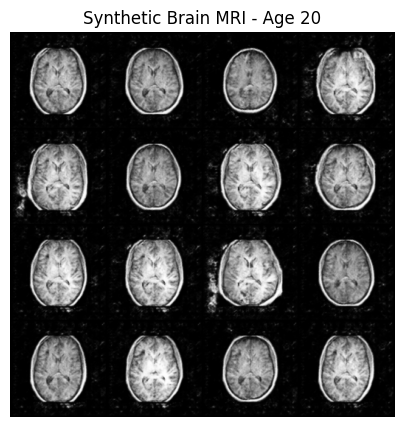

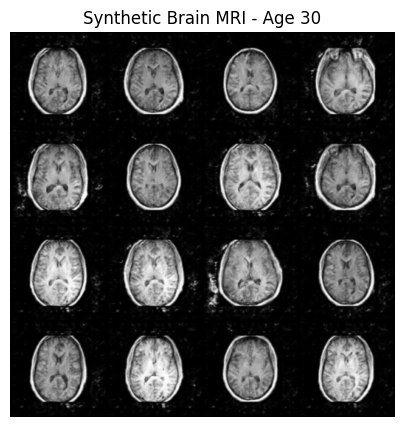

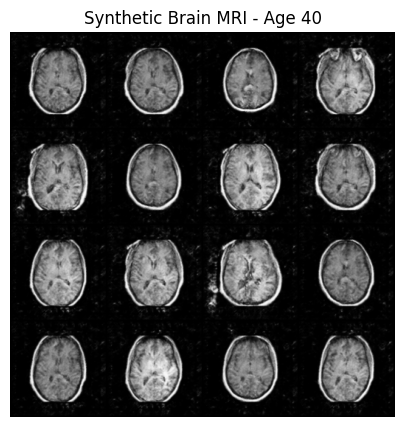

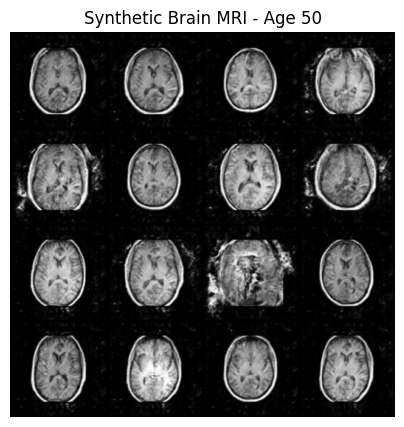

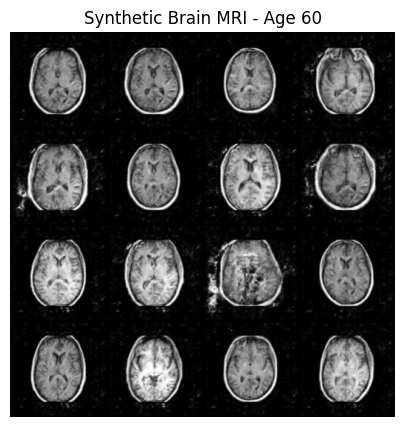

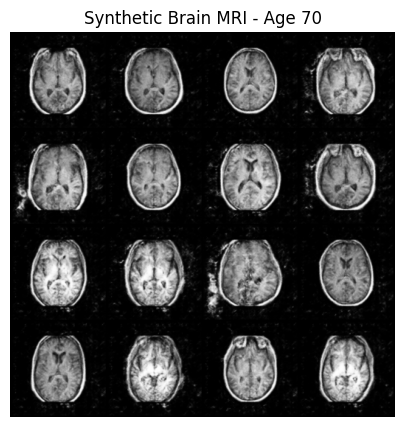

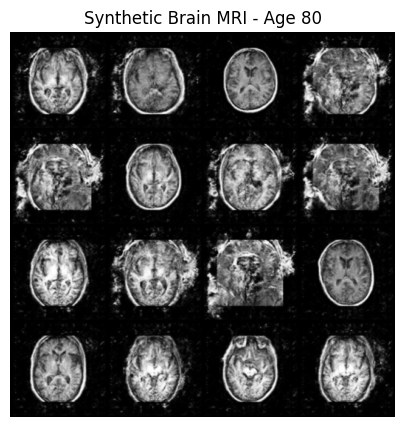

In [16]:
netG.eval()  

for idx, age in enumerate(age_classes):
    labels = torch.full((64,), idx, dtype=torch.long, device=device)
    with torch.no_grad():
        fake_imgs = netG(fixed_noise, labels)
    show_image_tensor(fake_imgs, title=f"Synthetic Brain MRI - Age {age}")


In [17]:
import torch
import torchvision.utils as vutils
import os
from PIL import Image
import numpy as np

def generate_and_save_individual_images(
    netG,
    nz=100,
    device="cuda",
    output_dir="generated_individual_samples",
    num_images_per_class=16,
    age_classes=[20, 30, 40, 50, 60, 70, 80]
):
    os.makedirs(output_dir, exist_ok=True)
    netG.eval()

    for idx, age in enumerate(age_classes):
        label_tensor = torch.full((num_images_per_class,), idx, dtype=torch.long, device=device)
        noise = torch.randn(num_images_per_class, nz, 1, 1, device=device)

        with torch.no_grad():
            fake_images = netG(noise, label_tensor).detach().cpu()  # (B, 1, 64, 64)

        save_folder = os.path.join(output_dir, f"age_{age}")
        os.makedirs(save_folder, exist_ok=True)

        for i in range(num_images_per_class):
            img = fake_images[i]
            img = (img * 0.5 + 0.5).clamp(0, 1)  # từ [-1,1] → [0,1]
            img_np = img.squeeze().numpy() * 255
            img_pil = Image.fromarray(img_np.astype(np.uint8), mode="L")
            img_pil.save(os.path.join(save_folder, f"fake_{i:02}.png"))

        print(f" Saved {num_images_per_class} images for age {age} → {save_folder}")


In [18]:
netG = Generator(nz=100, ngf=128, nc=1, n_classes=7).to(device)
netG.load_state_dict(torch.load("checkpoints/netG_epoch_699.pth", map_location=device))
generate_and_save_individual_images(netG, device=device)

✅ Saved 16 images for age 20 → generated_individual_samples/age_20
✅ Saved 16 images for age 30 → generated_individual_samples/age_30
✅ Saved 16 images for age 40 → generated_individual_samples/age_40
✅ Saved 16 images for age 50 → generated_individual_samples/age_50
✅ Saved 16 images for age 60 → generated_individual_samples/age_60
✅ Saved 16 images for age 70 → generated_individual_samples/age_70
✅ Saved 16 images for age 80 → generated_individual_samples/age_80


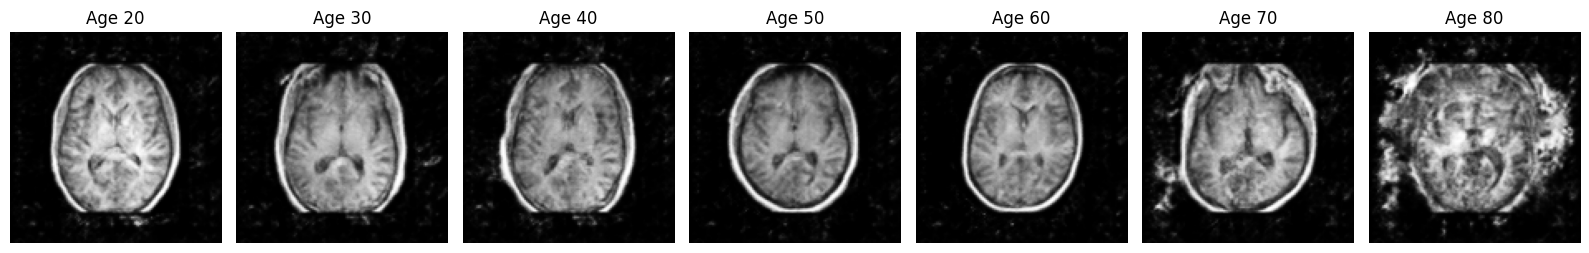

In [19]:
import os
import random
from PIL import Image
import matplotlib.pyplot as plt


age_classes = [20, 30, 40, 50, 60, 70, 80]
root_dir = "generated_individual_samples"

fig, axes = plt.subplots(1, len(age_classes), figsize=(16, 3))

for idx, age in enumerate(age_classes):
    age_folder = os.path.join(root_dir, f"age_{age}")
    image_files = os.listdir(age_folder)
    selected_image = random.choice(image_files)

    img_path = os.path.join(age_folder, selected_image)
    img = Image.open(img_path)

    axes[idx].imshow(img, cmap='gray')
    axes[idx].set_title(f"Age {age}")
    axes[idx].axis("off")

plt.tight_layout()
plt.show()


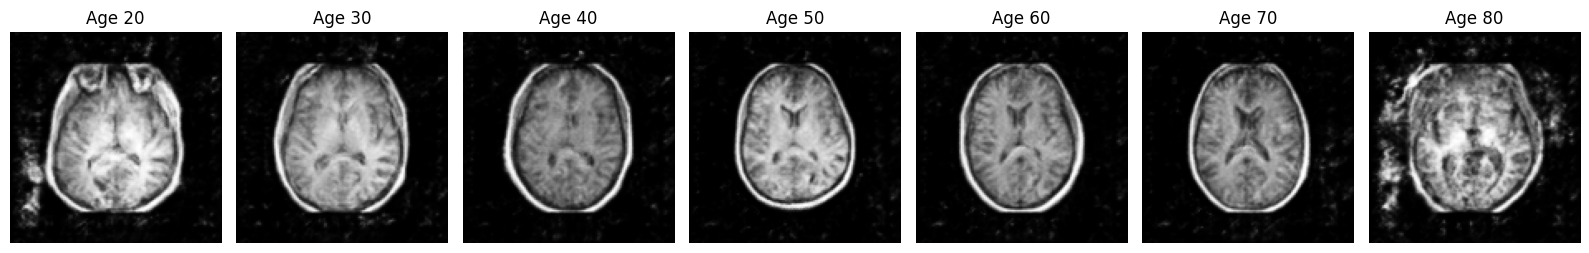

In [20]:
import os
from PIL import Image
import matplotlib.pyplot as plt

age_classes = [20, 30, 40, 50, 60, 70, 80]
root_dir = "generated_individual_samples"


image_name = "fake_01.png"

fig, axes = plt.subplots(1, len(age_classes), figsize=(16, 3))

for idx, age in enumerate(age_classes):
    img_path = os.path.join(root_dir, f"age_{age}", image_name)
    img = Image.open(img_path)

    axes[idx].imshow(img, cmap='gray')
    axes[idx].set_title(f"Age {age}")
    axes[idx].axis("off")

plt.tight_layout()
plt.show()


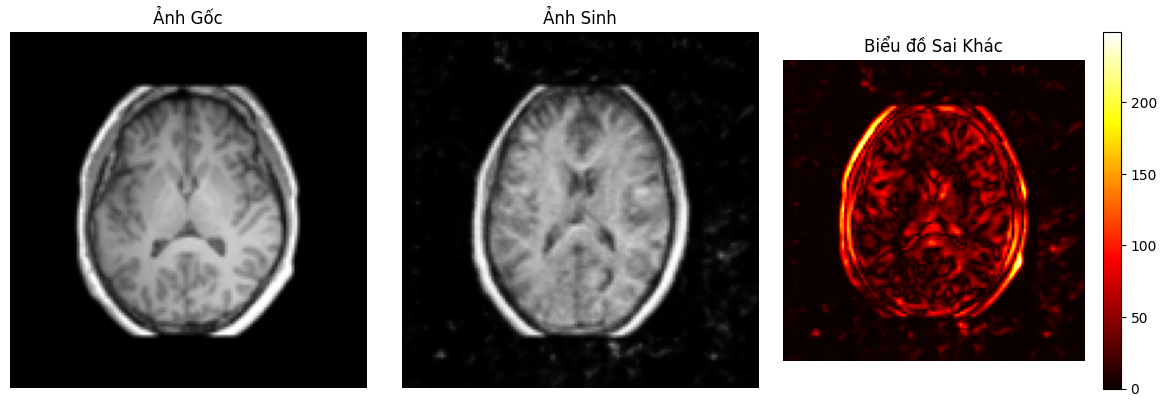

In [21]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# --- Config ---
age = 30  

gen_path = f"generated_individual_samples/age_{age}/fake_00.png"
real_dir = f"middle_slices/{age}"
real_name = os.listdir(real_dir)[0]  
real_path = os.path.join(real_dir, real_name)


img_gen = Image.open(gen_path).convert("L")  
img_real = Image.open(real_path).convert("L").resize(img_gen.size)


arr_gen = np.array(img_gen).astype(np.float32)
arr_real = np.array(img_real).astype(np.float32)


diff = np.abs(arr_gen - arr_real)


plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(arr_real, cmap='gray')
plt.title("Ảnh Gốc")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(arr_gen, cmap='gray')
plt.title("Ảnh Sinh")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(diff, cmap='hot')
plt.title("Biểu đồ Sai Khác")
plt.colorbar()
plt.axis("off")

plt.tight_layout()
plt.show()



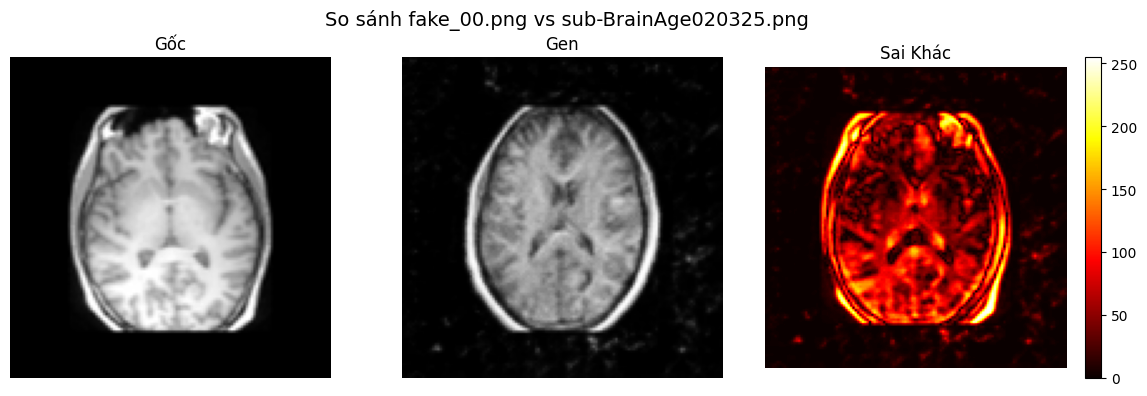

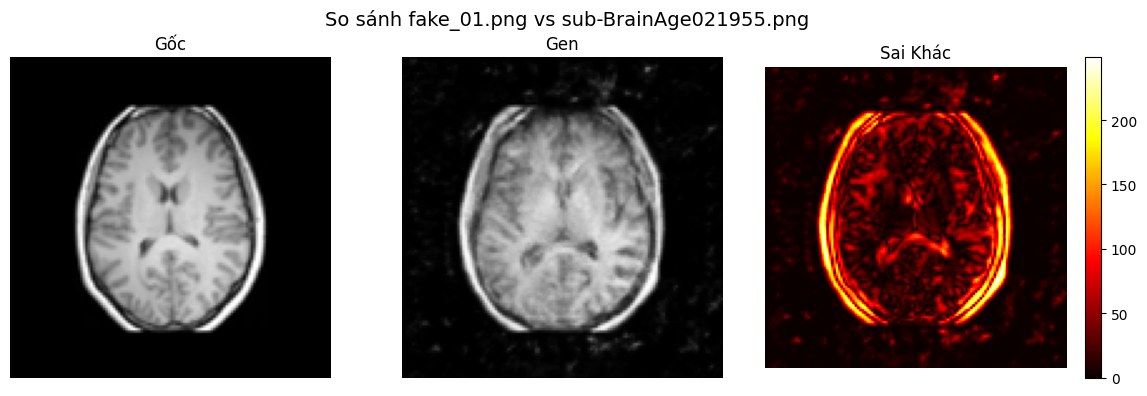

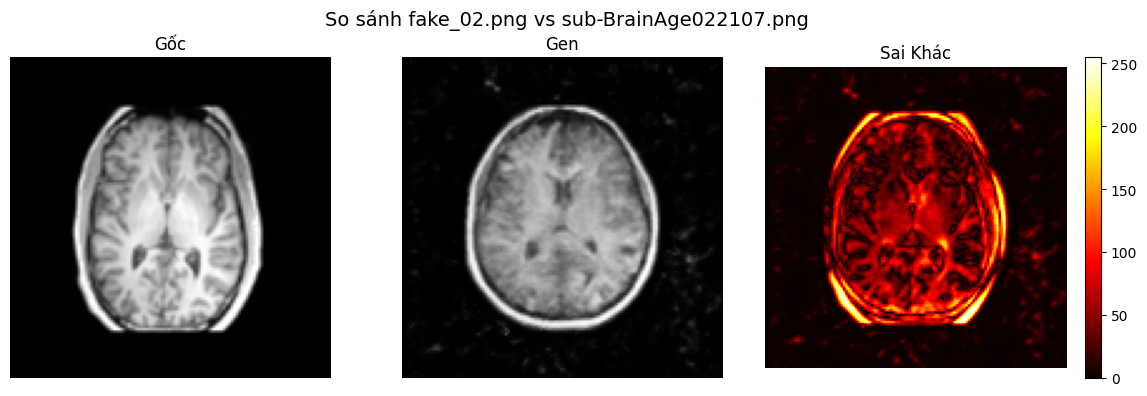

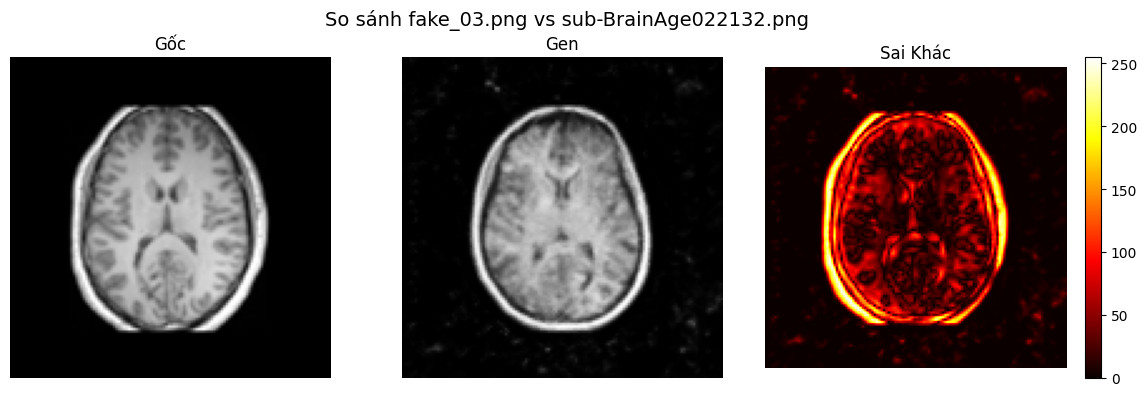

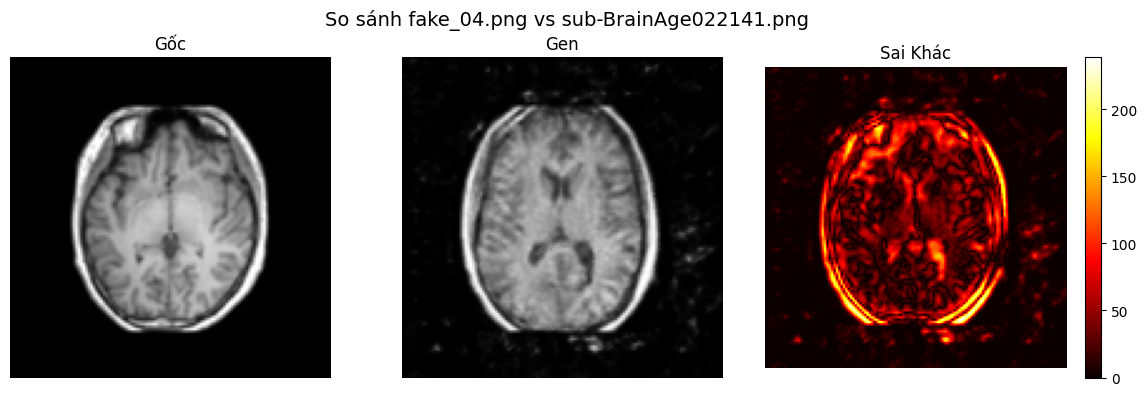

In [22]:
age = 30
gen_dir = f"generated_individual_samples/age_{age}"
real_dir = f"middle_slices/{age}"

gen_images = sorted(os.listdir(gen_dir))[:5]
real_images = sorted(os.listdir(real_dir))[:5]

for g, r in zip(gen_images, real_images):
    img_gen = Image.open(os.path.join(gen_dir, g)).convert("L")
    img_real = Image.open(os.path.join(real_dir, r)).convert("L").resize(img_gen.size)

    arr_gen = np.array(img_gen).astype(np.float32)
    arr_real = np.array(img_real).astype(np.float32)
    diff = np.abs(arr_gen - arr_real)

    # Hiển thị
    plt.figure(figsize=(12, 4))
    plt.suptitle(f"So sánh {g} vs {r}", fontsize=14)

    plt.subplot(1, 3, 1)
    plt.imshow(arr_real, cmap='gray')
    plt.title("Gốc")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(arr_gen, cmap='gray')
    plt.title("Gen")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(diff, cmap='hot')
    plt.title("Sai Khác")
    plt.colorbar()
    plt.axis("off")

    plt.tight_layout()
    plt.show()


✔️ Age 20 → SSIM: 0.3665
✔️ Age 30 → SSIM: 0.4050
✔️ Age 40 → SSIM: 0.4188
✔️ Age 50 → SSIM: 0.3312
✔️ Age 60 → SSIM: 0.3309
✔️ Age 70 → SSIM: 0.3588
✔️ Age 80 → SSIM: 0.2354


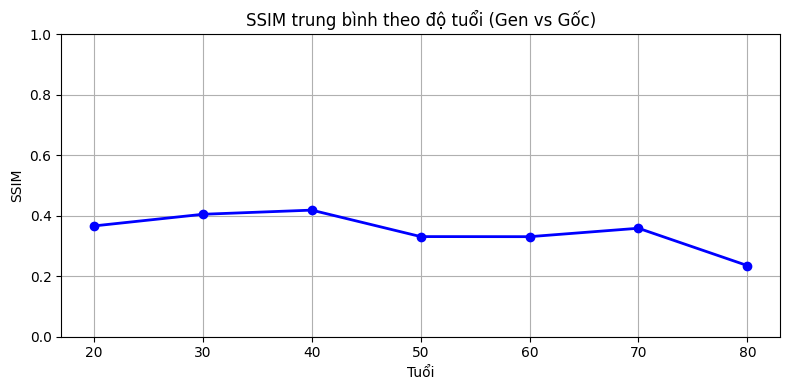

In [23]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from skimage.metrics import structural_similarity as ssim

def compute_ssim_for_age(age_dir_gen, age_dir_real):
    gen_images = sorted(os.listdir(age_dir_gen))
    real_images = sorted(os.listdir(age_dir_real))
    scores = []

    for g, r in zip(gen_images, real_images):
        gen_path = os.path.join(age_dir_gen, g)
        real_path = os.path.join(age_dir_real, r)

        # resize
        img_gen = Image.open(gen_path).convert("L")
        img_real = Image.open(real_path).convert("L").resize(img_gen.size)

        arr_gen = np.array(img_gen).astype(np.float32)
        arr_real = np.array(img_real).astype(np.float32)

        
        ssim_score = ssim(arr_real, arr_gen, data_range=255)
        scores.append(ssim_score)
    
    return np.mean(scores)

# --- Danh sách độ tuổi ---
age_classes = [20, 30, 40, 50, 60, 70, 80]
ssim_results = []

# --- Tính SSIM theo từng độ tuổi ---
for age in age_classes:
    path_gen = f"generated_individual_samples/age_{age}"
    path_real = f"middle_slices/{age}"

    if os.path.exists(path_gen) and os.path.exists(path_real):
        score = compute_ssim_for_age(path_gen, path_real)
        ssim_results.append(score)
        print(f" Age {age} → SSIM: {score:.4f}")
    else:
        ssim_results.append(None)
        print(f" Age {age} → thiếu thư mục ảnh")

# --- Plot ---
valid_ages = [age for age, score in zip(age_classes, ssim_results) if score is not None]
valid_scores = [score for score in ssim_results if score is not None]

plt.figure(figsize=(8, 4))
plt.plot(valid_ages, valid_scores, marker='o', color='blue', linewidth=2)
plt.title("SSIM trung bình theo độ tuổi (Gen vs Gốc)")
plt.xlabel("Tuổi")
plt.ylabel("SSIM")
plt.ylim(0, 1)
plt.grid(True)
plt.tight_layout()
plt.show()


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


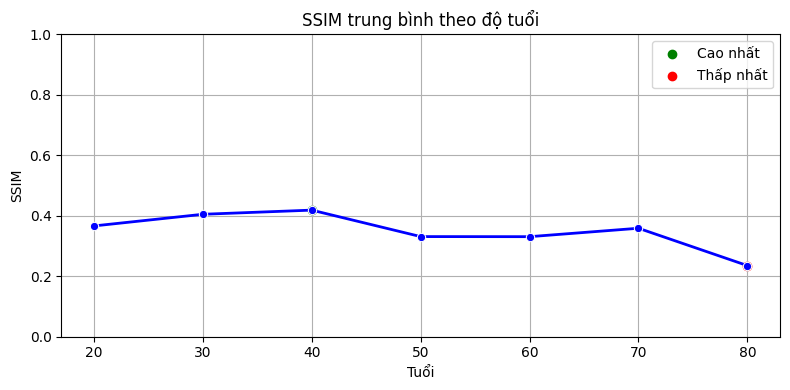

In [24]:
import seaborn as sns

plt.figure(figsize=(8, 4))
sns.lineplot(x=valid_ages, y=valid_scores, marker='o', linewidth=2, color='blue')

max_idx = np.argmax(valid_scores)
min_idx = np.argmin(valid_scores)

plt.scatter(valid_ages[max_idx], valid_scores[max_idx], color='green', label='Cao nhất')
plt.scatter(valid_ages[min_idx], valid_scores[min_idx], color='red', label='Thấp nhất')

plt.title("SSIM trung bình theo độ tuổi")
plt.xlabel("Tuổi")
plt.ylabel("SSIM")
plt.ylim(0, 1)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


### FID

In [3]:
pip install torchmetrics



  Using cached torchmetrics-1.7.2-py3-none-any.whl.metadata (21 kB)
  Using cached lightning_utilities-0.14.3-py3-none-any.whl.metadata (5.6 kB)
Using cached torchmetrics-1.7.2-py3-none-any.whl (962 kB)
Using cached lightning_utilities-0.14.3-py3-none-any.whl (28 kB)



[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
pip install torch-fidelity


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from torchmetrics.image.fid import FrechetInceptionDistance
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


transform = transforms.Compose([
    transforms.Resize((299, 299)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),  # will be in [0, 1] float32
])

real_dir = "D:/Work/Yte/DCGAN/Attribute-Driven_Counterfactual_Brain_MRI_with_GANs/Attribute-Driven_Counterfactual_Brain_MRI_with_GANs/src/DCGAN/results/middle_slices"  
fake_dir = "D:/Work/Yte/DCGAN/Attribute-Driven_Counterfactual_Brain_MRI_with_GANs/Attribute-Driven_Counterfactual_Brain_MRI_with_GANs/src/DCGAN/results/generated_individual_samples"  

real_dataset = datasets.ImageFolder(root=real_dir, transform=transform)
fake_dataset = datasets.ImageFolder(root=fake_dir, transform=transform)

real_loader = DataLoader(real_dataset, batch_size=64, shuffle=False)
fake_loader = DataLoader(fake_dataset, batch_size=64, shuffle=False)


fid = FrechetInceptionDistance(feature=2048).to(device)

for imgs, _ in tqdm(real_loader, desc="Embedding real"):
    imgs = (imgs * 255).clamp(0, 255).to(torch.uint8).to(device)  # normalize về [0, 255]
    fid.update(imgs, real=True)


for imgs, _ in tqdm(fake_loader, desc="Embedding fake"):
    imgs = (imgs * 255).clamp(0, 255).to(torch.uint8).to(device)
    fid.update(imgs, real=False)


score = fid.compute()
print(f"✅ FID score: {score.item():.2f}")

Embedding fake: 100%|██████████| 2/2 [00:17<00:00,  8.63s/it]


✅ FID score: 173.11
